# **Notebook Description**
---
This notebook includes:
- **Data Loading** – Import the dataset.
- **Data Wrangling** – Clean and prepare the data.
- **Exploratory Data Analysis (EDA)** – Explore patterns and relationships.
- **Preprocessing & Encoding** – Prepare features for modeling.
- **Feature Engineering** – Create new features.
- **Model Building** – Train and evaluate models.


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import plotly.express as px


import warnings
warnings.filterwarnings('ignore')

In [86]:
# Load Data
pd.set_option("display.max_columns", None)
df = pd.read_csv("D:\Depi_project\Data\SalesScope_Data.csv")


## **Data Wrangling**

In [87]:
# Show First Rows of Dataset
df.head()

,SalesOrderID,OrderDate,DueDate,ShipDate,CustomerID,TerritoryID,SubTotal,TaxAmt,Freight,TotalDue,SalesOrderDetailID,OrderQty,ProductID,LineTotal,ProductCategoryID,Category,ProductSubcategoryID,Sub category,Product.1,Color,Territory
0,52242,7/7/2013,7/19/2013,7/14/2013,18102,4,4.99,0.3992,0.1248,5.514,43795,1,870,4.99,4,Accessories,28,Bottles and Cages,Water Bottle - 30 oz.,No color,Southwest
1,52592,7/14/2013,7/26/2013,7/21/2013,17014,4,4.99,0.3992,0.1248,5.514,44665,1,870,4.99,4,Accessories,28,Bottles and Cages,Water Bottle - 30 oz.,No color,Southwest
2,52694,7/16/2013,7/28/2013,7/23/2013,17165,4,4.99,0.3992,0.1248,5.514,44911,1,870,4.99,4,Accessories,28,Bottles and Cages,Water Bottle - 30 oz.,No color,Southwest
3,52799,7/18/2013,7/30/2013,7/25/2013,18111,4,4.99,0.3992,0.1248,5.514,45168,1,870,4.99,4,Accessories,28,Bottles and Cages,Water Bottle - 30 oz.,No color,Southwest
4,53799,8/3/2013,8/15/2013,8/10/2013,18123,4,4.99,0.3992,0.1248,5.514,50911,1,870,4.99,4,Accessories,28,Bottles and Cages,Water Bottle - 30 oz.,No color,Southwest


In [88]:
# Display Info About Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82610 entries, 0 to 82609
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SalesOrderID          82610 non-null  int64  
 1   OrderDate             82610 non-null  object 
 2   DueDate               82610 non-null  object 
 3   ShipDate              82610 non-null  object 
 4   CustomerID            82610 non-null  int64  
 5   TerritoryID           82610 non-null  int64  
 6   SubTotal              82610 non-null  float64
 7   TaxAmt                82610 non-null  float64
 8   Freight               82610 non-null  float64
 9   TotalDue              82610 non-null  float64
 10  SalesOrderDetailID    82610 non-null  int64  
 11  OrderQty              82610 non-null  int64  
 12  ProductID             82610 non-null  int64  
 13  LineTotal             82610 non-null  float64
 14  ProductCategoryID     82610 non-null  int64  
 15  Category           

**Note:**
- **OrderDate, DueDate, ShipDate**,  Columns should be converted from object to datetime.

In [89]:
# Check for missing values
df.isnull().sum()

SalesOrderID            0
OrderDate               0
DueDate                 0
ShipDate                0
CustomerID              0
TerritoryID             0
SubTotal                0
TaxAmt                  0
Freight                 0
TotalDue                0
SalesOrderDetailID      0
OrderQty                0
ProductID               0
LineTotal               0
ProductCategoryID       0
Category                0
ProductSubcategoryID    0
Sub category            0
Product.1               0
Color                   0
Territory               1
dtype: int64

In [90]:
# Only one missing value in 'Territory', safe to drop
df = df.dropna(subset=['Territory'])

In [91]:
# Cleanning of 'OrderDate' Column
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['OrderDay'] = pd.to_datetime(df['OrderDate']).dt.day
df['OrderMonth'] = pd.to_datetime(df['OrderDate']).dt.month
df['OrderYear'] = pd.to_datetime(df['OrderDate']).dt.year

In [92]:
# Cleanning of 'DueDate' Column
df['DueDate'] = pd.to_datetime(df['DueDate'])
df['DueDay'] = pd.to_datetime(df['DueDate']).dt.day
df['DueMonth'] = pd.to_datetime(df['DueDate']).dt.month
df['DueYear'] = pd.to_datetime(df['DueDate']).dt.year


In [93]:
# Cleanning of 'ShipDate' Column
df['ShipDate'] = pd.to_datetime(df['ShipDate'])
df['ShipDay'] = pd.to_datetime(df['ShipDate']).dt.day
df['ShipMonth'] = pd.to_datetime(df['ShipDate']).dt.month
df['ShipYear'] = pd.to_datetime(df['ShipDate']).dt.year

In [94]:
# Get all unique values in the 'Product.1' column
df['Product.1'].unique()

array(['Water Bottle - 30 oz.', 'Mountain Tire Tube', 'Touring Tire Tube',
       'Sport-100 Helmet, Black', 'Sport-100 Helmet, Blue',
       'Sport-100 Helmet, Red', 'Mountain-100 Silver, 44',
       'Mountain-100 Black, 48', 'Mountain-100 Black, 38',
       'Mountain Bike Socks, L', 'Mountain-100 Black, 42',
       'Road-450 Red, 58', 'Long-Sleeve Logo Jersey, L',
       'Road-650 Black, 52', 'HL Mountain Frame - Silver, 48',
       'HL Mountain Frame - Black, 48', 'Road-650 Red, 48',
       'HL Mountain Frame - Silver, 38', 'HL Mountain Frame - Silver, 46',
       'Long-Sleeve Logo Jersey, M', 'Road-650 Red, 62',
       'Road-650 Red, 60', 'Road-150 Red, 56', 'ML Road Frame - Red, 48',
       'Road-650 Red, 44', 'Mountain-100 Silver, 38',
       'Mountain-100 Silver, 42', 'LL Road Frame - Red, 44',
       'LL Road Frame - Black, 58', 'LL Road Frame - Black, 52',
       'LL Road Frame - Red, 62', 'Mountain-100 Black, 44',
       'AWC Logo Cap', 'Road-650 Black, 58', 'Road-450 Red, 44

In [95]:
# Define functions to extract information from the 'Product.1' column
def extract_size(product):
    match = re.search(r'(?:, )?(\d+\s*oz\.|\d+|XS|S|M|L|XL|XXL)$', product)
    if match:
        return match.group(1)
    return None

def extract_type(product):
    match = re.match(r'^(HL|ML|LL)\b', product.strip())
    if match:
        return match.group(1)
    return None

def extract_name(product):
    name = re.sub(r'^(HL|ML|LL)\s*', '', product).strip()
    name = re.sub(r'(?:- )?(\d+\s*oz\.|\d+|XS|S|M|L|XL|XXL)$', '', name).strip()
    name = re.sub(r'(, )?(Black|Blue|Red|Yellow|Silver|Multi|White|Green|Orange|Purple|Gray)\b', '', name).strip()
    name = re.sub(r'[, -]+$', '', name).strip()
    return name.lower()

df['ProductName'] = df['Product.1'].apply(extract_name)
df['Size'] = df['Product.1'].apply(extract_size)
df['ProductType'] = df['Product.1'].apply(extract_type)

Checking for unique values and data consistency

In [96]:
# Get all unique values in the 'ProductName' column
df['ProductName'].unique()

array(['water bottle', 'mountain tire tube', 'touring tire tube',
       'sport-100 helmet', 'mountain-100', 'mountain bike socks',
       'road-450', 'long-sleeve logo jersey', 'road-650',
       'mountain frame', 'road-150', 'road frame', 'awc logo cap',
       'road front wheel', 'road frame-w', 'mountain-200',
       'mountain handlebars', "women's tights", 'half-finger gloves',
       'road-250', 'headset', 'mountain front wheel', "men's bib-shorts",
       'mountain rear wheel', 'mountain-300', 'fork', 'cable lock',
       'road rear wheel', 'full-finger gloves', 'road-550-w',
       "men's sports shorts", 'minipump', 'road handlebars', 'road pedal',
       'road-750', 'chain', 'touring-1000', 'mountain pedal',
       'road-350-w', 'mountain-500', 'rear derailleur',
       'mountain frame-w', 'crankset', 'touring frame',
       'touring seat/saddle', 'touring pedal', 'classic vest',
       "women's mountain shorts", 'short-sleeve classic jersey',
       'road seat/saddle', 'mount

In [97]:
# Get all unique values in the 'Size' column
df['Size'].unique()

array(['30 oz.', None, '44', '48', '38', 'L', '42', '58', '52', '46', 'M',
       '62', '60', '56', 'XL', 'S', '40', '50', '54', '70 oz.'],
      dtype=object)

In [98]:
# Count how many of each product type we have
df['ProductType'].value_counts()

ProductType
HL    5300
LL    5118
ML    4029
Name: count, dtype: int64

In [99]:
# Check how many missing values are left in 'ProductType' and 'Size' columns
df[['ProductType', 'Size']].isna().sum()

ProductType    68162
Size           37953
dtype: int64

**Notes**:

- Column **ProductType** has many missing values, so it will be dropped.

In [100]:
# Drop Column
df = df.drop(columns=['ProductType'])

In [101]:
# Fill missing values with "No size"
df["Size"] = df["Size"].fillna("No size")

In [102]:
# Color values cleaned: stripped and converted to title case.
df["Color"] = df["Color"].str.strip().str.title()

In [103]:
# Remove the original 'Product.1' column
df = df.drop(columns=['Product.1'])

Added new column **ItemsInOrder** counting products per SalesOrderID; will be used for analysis and modeling.

In [104]:
df["ItemsInOrder"] = df.groupby("SalesOrderID")["ProductID"].transform("count")

## **Outliers Handling**


In [105]:
# Display summary statistics
df.describe()

,SalesOrderID,OrderDate,DueDate,ShipDate,CustomerID,TerritoryID,SubTotal,TaxAmt,Freight,TotalDue,SalesOrderDetailID,OrderQty,ProductID,LineTotal,ProductCategoryID,ProductSubcategoryID,OrderDay,OrderMonth,OrderYear,DueDay,DueMonth,DueYear,ShipDay,ShipMonth,ShipYear,ItemsInOrder
count,82609.000000,82609,82609,82609,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000,82609.000000
mean,59644.398504,2013-09-01 16:34:33.304361472,2013-09-13 16:34:44.809161216,2013-09-08 16:34:44.809161216,21788.965101,5.740295,9536.675274,915.956963,286.236569,10738.868806,67830.429094,1.092665,847.411372,539.288861,2.727645,19.570737,18.239465,6.386060,2013.174085,14.741529,6.396531,2013.215558,13.311806,6.389231,2013.206382,5.080718
min,43659.000000,2011-05-31 00:00:00,2011-06-12 00:00:00,2011-06-07 00:00:00,11000.000000,1.000000,1.374000,0.109900,0.034400,1.518300,1.000000,1.000000,707.000000,1.374000,1.000000,1.000000,1.000000,1.000000,2011.000000,1.000000,1.000000,2011.000000,1.000000,1.000000,2011.000000,1.000000
25%,52112.000000,2013-07-05 00:00:00,2013-07-17 00:00:00,2013-07-12 00:00:00,15396.000000,4.000000,74.980000,5.998400,1.874500,82.852900,43484.000000,1.000000,776.000000,9.990000,1.000000,2.000000,9.000000,3.000000,2013.000000,10.000000,4.000000,2013.000000,7.000000,4.000000,2013.000000,2.000000
50%,59546.000000,2013-11-05 00:00:00,2013-11-17 00:00:00,2013-11-12 00:00:00,21978.000000,6.000000,1248.830000,99.987200,31.246000,1381.073200,71689.000000,1.000000,870.000000,35.000000,3.000000,21.000000,19.000000,6.000000,2013.000000,12.000000,6.000000,2013.000000,10.000000,6.000000,2013.000000,3.000000
75%,67332.000000,2014-03-01 00:00:00,2014-03-13 00:00:00,2014-03-08 00:00:00,29523.000000,9.000000,3578.270000,286.261600,89.456800,3953.988400,96811.000000,1.000000,922.000000,713.796000,4.000000,31.000000,29.000000,9.000000,2014.000000,21.000000,9.000000,2014.000000,21.000000,10.000000,2014.000000,5.000000
max,75123.000000,2014-06-30 00:00:00,2014-07-12 00:00:00,2014-07-07 00:00:00,30118.000000,10.000000,163930.394300,17948.518600,5608.912100,187487.825000,121317.000000,2.000000,999.000000,4293.924000,4.000000,37.000000,31.000000,12.000000,2014.000000,31.000000,12.000000,2014.000000,31.000000,12.000000,2014.000000,29.000000
std,8902.802400,NaN,NaN,NaN,6723.616596,2.913628,18831.489109,1844.219560,576.318605,21248.506515,34113.619319,0.289965,86.693163,905.088640,1.307492,13.848851,10.317605,3.452876,0.798670,7.758265,3.445000,0.801251,8.498237,3.449724,0.799571,5.189508


In [106]:
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 -Q1

    lower_bound =Q1 - 1.5 *IQR
    upper_bound =Q3 + 1.5 *IQR

    df[column] = df[column].where(df[column] >= lower_bound, lower_bound)
    df[column] = df[column].where(df[column] <= upper_bound, upper_bound)

    return df

numeric_columns = ['SubTotal', 'TaxAmt', 'Freight', 'TotalDue',
                   'OrderQty', 'LineTotal']

for col in numeric_columns:
    df = handle_outliers(df, col)

In [107]:
# Checking Duplicated Data
df.duplicated().sum()

0

Note:
- there is no duplicate data.

## **Exploratory Data Analysis (EDA)**


In [108]:
df.sample(5)

,SalesOrderID,OrderDate,DueDate,ShipDate,CustomerID,TerritoryID,SubTotal,TaxAmt,Freight,TotalDue,SalesOrderDetailID,OrderQty,ProductID,LineTotal,ProductCategoryID,Category,ProductSubcategoryID,Sub category,Color,Territory,OrderDay,OrderMonth,OrderYear,DueDay,DueMonth,DueYear,ShipDay,ShipMonth,ShipYear,ProductName,Size,ItemsInOrder
56375,67020,2014-02-25,2014-03-09,2014-03-04,26155,9,128.970,10.3176,3.22430,142.51190,94726,1,716,49.990,3,Clothing,21,Jerseys,Multi,Australia,25,2,2014,9,3,2014,4,3,2014,long-sleeve logo jersey,XL,3
43607,74819,2014-06-21,2014-07-03,2014-06-28,25763,1,38.880,3.1104,0.97200,42.96240,120608,1,873,2.290,4,Accessories,37,Tires and Tubes,No Color,Northwest,21,6,2014,3,7,2014,28,6,2014,patch kit/8 patches,No size,3
38149,46034,2012-03-30,2012-04-11,2012-04-06,29892,6,8833.205,706.6564,220.83025,9760.69165,8405,1,757,874.794,1,Bikes,2,Road Bikes,Red,Canada,30,3,2012,11,4,2012,6,4,2012,road-450,48,20
25786,67472,2014-03-02,2014-03-14,2014-03-09,24099,8,563.770,45.1016,14.09430,622.96590,97411,1,999,539.990,1,Bikes,2,Road Bikes,Black,Germany,2,3,2014,14,3,2014,9,3,2014,road-750,52,3
32926,68313,2014-03-15,2014-03-27,2014-03-22,12590,10,58.470,4.6776,1.46180,64.60940,99486,1,934,28.990,4,Accessories,37,Tires and Tubes,No Color,United Kingdom,15,3,2014,27,3,2014,22,3,2014,touring tire,No size,3


### Which products are the most sold (top 10 ProductName by OrderQty)?

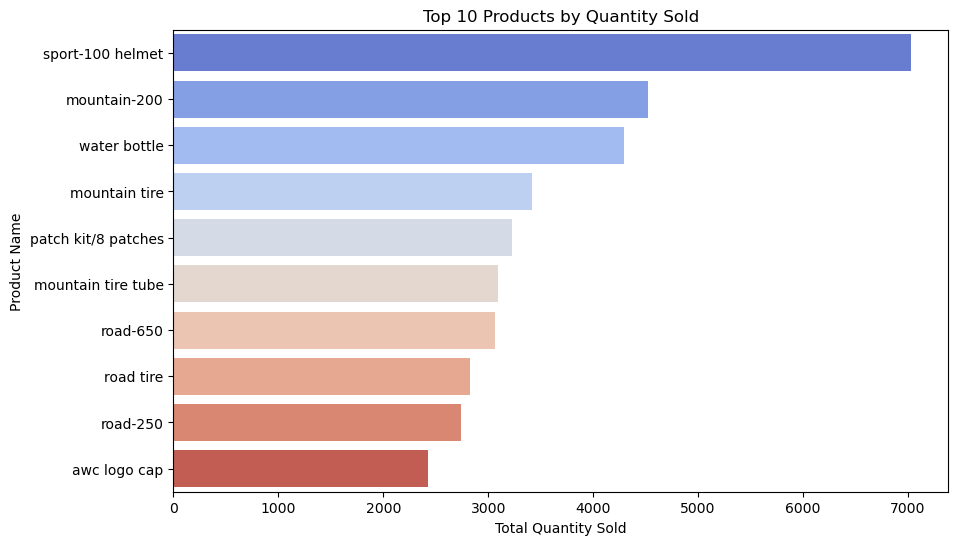

In [109]:
top_products = df.groupby("ProductName")["OrderQty"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="coolwarm")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Name")
plt.show()


### Which products have the highest total sales (based on TotalDue)?

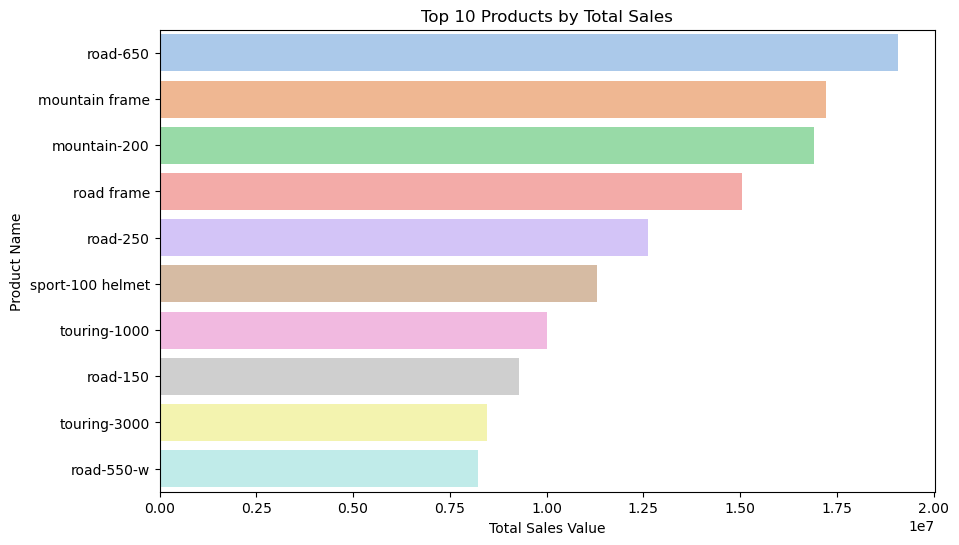

In [110]:
top_sales = (df.groupby('ProductName')['TotalDue'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,6))
sns.barplot(x=top_sales.values, y=top_sales.index, palette="pastel")
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales Value")
plt.ylabel("Product Name")
plt.show()


### Which categories generate the highest total sales (TotalDue)?  


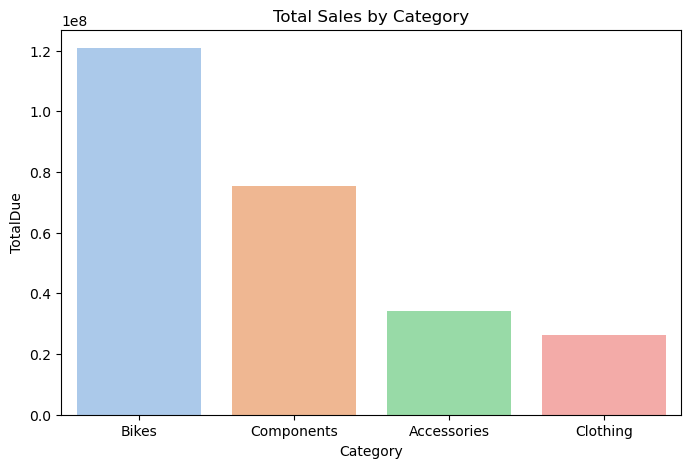

In [111]:
category_sales=df.groupby("Category")["TotalDue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='TotalDue', data=category_sales, estimator=sum, palette="pastel")
plt.title("Total Sales by Category")
plt.show()

### Which subcategories generate the highest sales?


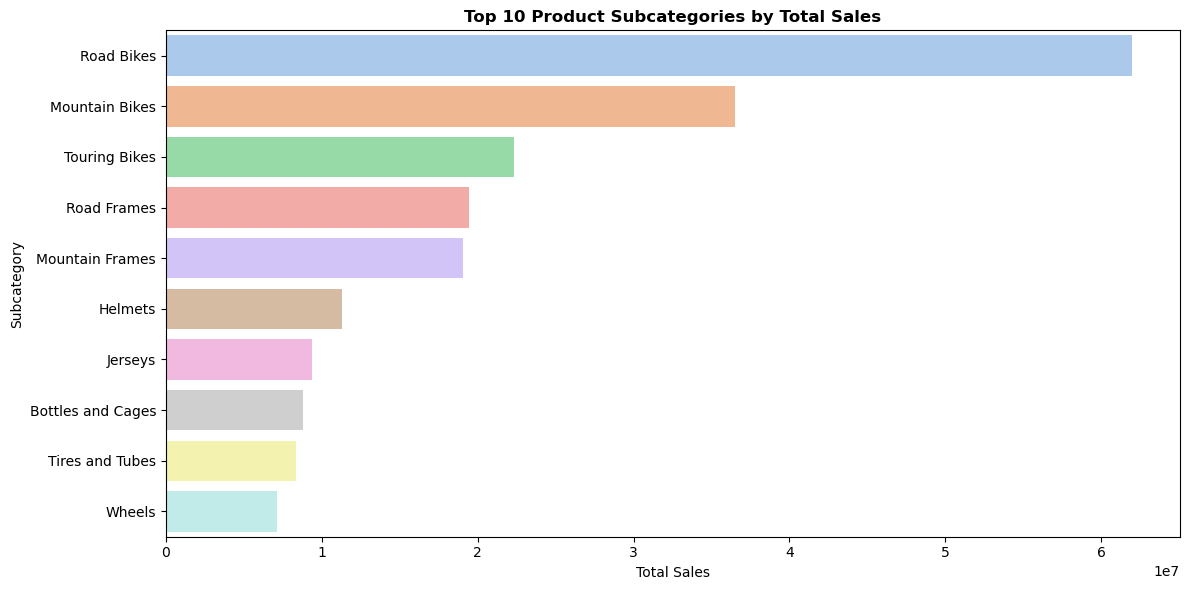

In [112]:
top_subcategories=df.groupby("Sub category")["TotalDue"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_subcategories,x="TotalDue",y="Sub category",palette="pastel")
plt.title("Top 10 Product Subcategories by Total Sales",fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Subcategory")
plt.tight_layout()
plt.show()

### What are the most popular Clothing sizes?

In [113]:
Clothing = df[df["Category"] == "Clothing"]

fig = px.histogram(Clothing,
                   x="Size",
                   title="Distribution of Clothing Products by Size",
                   color="Size")

fig.show()


### What are the most common bike frame sizes?

In [114]:
bikes_df = df[df["Category"] == "Bikes"]

fig = px.histogram(bikes_df,
                   x="Size",
                   title="Distribution of Bike Products by Size",
                   color="Size")

fig.show()


### What are the most common colors of products in the Clothing category?

In [115]:
Clothing = df[df["Category"] == "Clothing"]
fig = px.histogram(Clothing,
                   x="Color",
                   title="Distribution of Clothing Products by Color",
                   color="Color")

fig.show()


### What are the most common colors of products in the Bikes category?

In [116]:
bikes = df[df["Category"] == "Bikes"]
fig = px.histogram(bikes,
                   x="Color",
                   title="Distribution of Bike Products by Color",
                   color="Color")

fig.show()


### What are the most common colors of products in the Components category?

In [117]:
Components = df[df["Category"] == "Components"]
fig = px.histogram(Components,
                   x="Color",
                   title="Distribution of Components Products by Color",
                   color="Color")

fig.show()


### Which colors of Products have the highest prices?

In [118]:
fig = px.box(df, x="Color", y="TotalDue", title="Price Distribution by Color", color="Color")
fig.show()

### Which territories generate the highest total sales (TotalDue)?

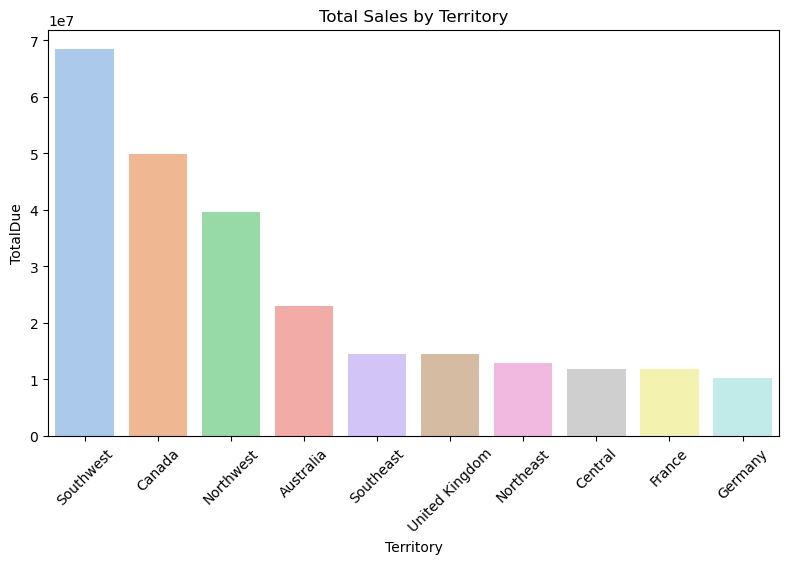

In [119]:
territory_sales=df.groupby("Territory")["TotalDue"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Territory', y='TotalDue', data=territory_sales, estimator=sum ,palette="pastel")
plt.title("Total Sales by Territory")
plt.tight_layout()
plt.xticks(rotation = 45)
plt.show()

### How many orders were placed each month across the years?

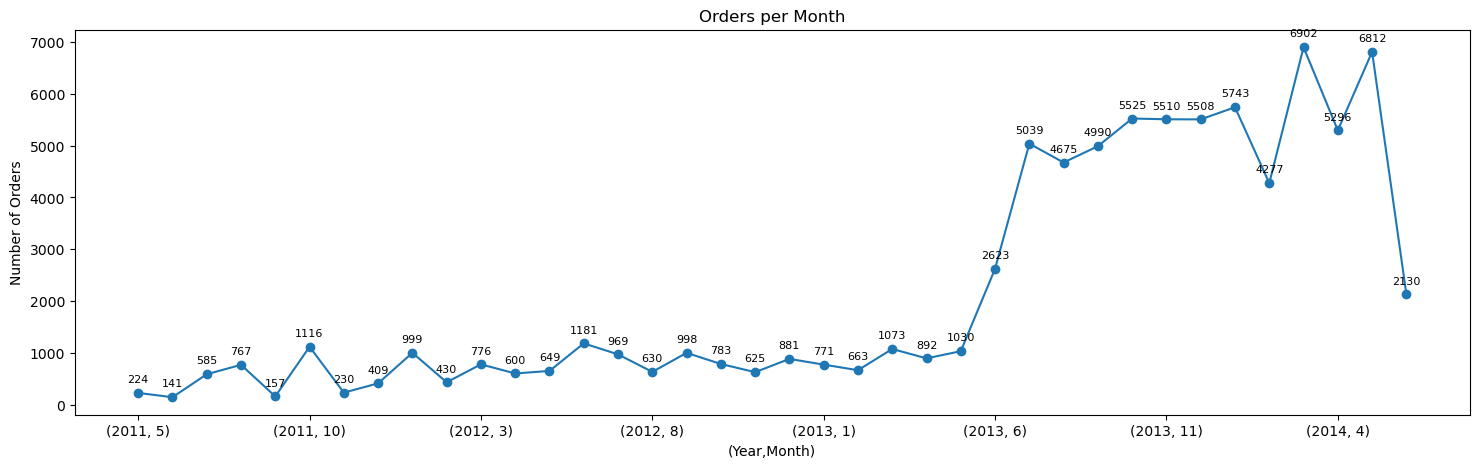

In [120]:
orders_per_month = df.groupby(['OrderYear','OrderMonth'])['SalesOrderID'].count()
ax = orders_per_month.plot(kind='line', figsize=(18,5), marker="o")

# Add values on points
for i, value in enumerate(orders_per_month):
    ax.text(i, value+200, str(value), ha='center', fontsize=8)

plt.title("Orders per Month")
plt.ylabel("Number of Orders")
plt.xlabel("(Year,Month)")

plt.show()


### What is the monthly sales trend over time?

In [121]:

sales_trend = df.groupby(df["OrderDate"].dt.to_period("M"))["TotalDue"].sum().reset_index()
sales_trend["OrderDate"] = sales_trend["OrderDate"].astype(str)
fig = px.line(sales_trend, x="OrderDate", y="TotalDue", title="Monthly Sales Trend")
fig.show()

### Which year contributed the highest percentage of total sales?


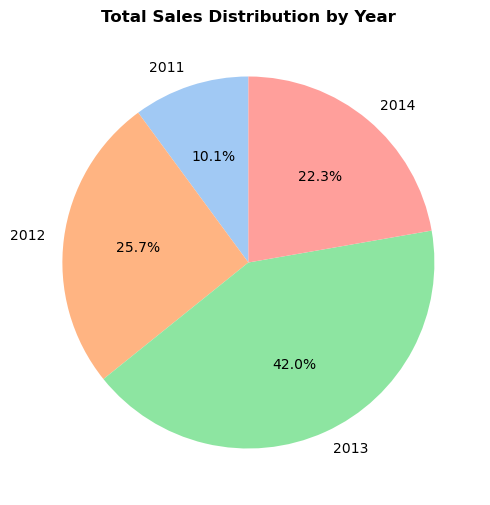

In [122]:
sales_by_year = df.groupby("OrderYear")["TotalDue"].sum().reset_index()

plt.figure(figsize=(6,7))
plt.pie(
    sales_by_year["TotalDue"],
    labels=sales_by_year["OrderYear"],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Total Sales Distribution by Year", fontweight="bold")
plt.show()


### How do sales vary by month?


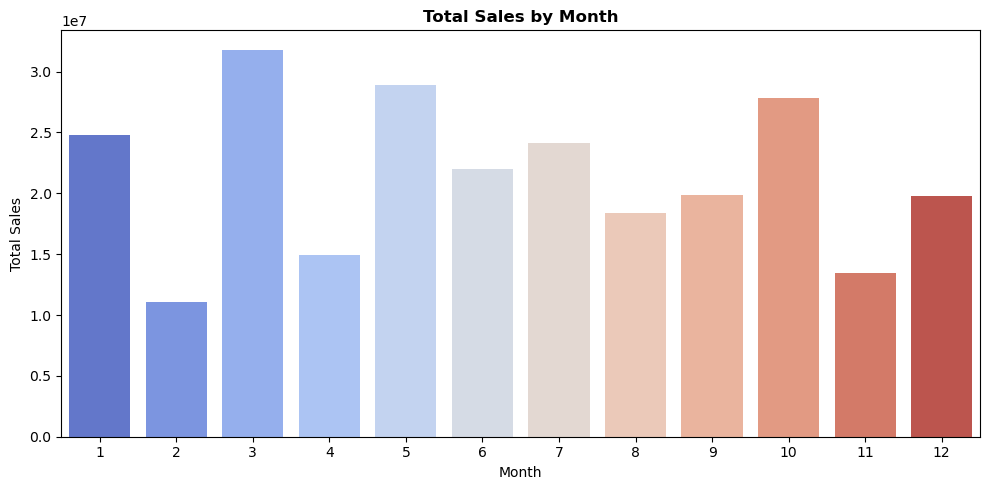

In [123]:
sales_by_month=df.groupby("OrderMonth")["TotalDue"].sum().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=sales_by_month,x="OrderMonth",y="TotalDue",palette="coolwarm")
plt.title("Total Sales by Month",fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### How do sales vary by day of the week


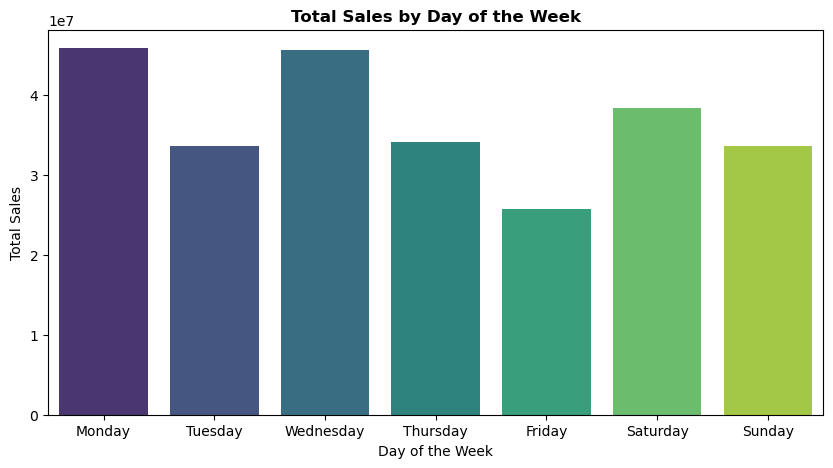

In [124]:
df['OrderDayOfWeek']=df['OrderDate'].dt.day_name()
sales_by_day=df.groupby("OrderDayOfWeek")["TotalDue"].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=sales_by_day,x="OrderDayOfWeek",y="TotalDue",palette="viridis")
plt.title("Total Sales by Day of the Week",fontweight="bold")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales")
plt.show()

### Do certain territories prefer specific categories?

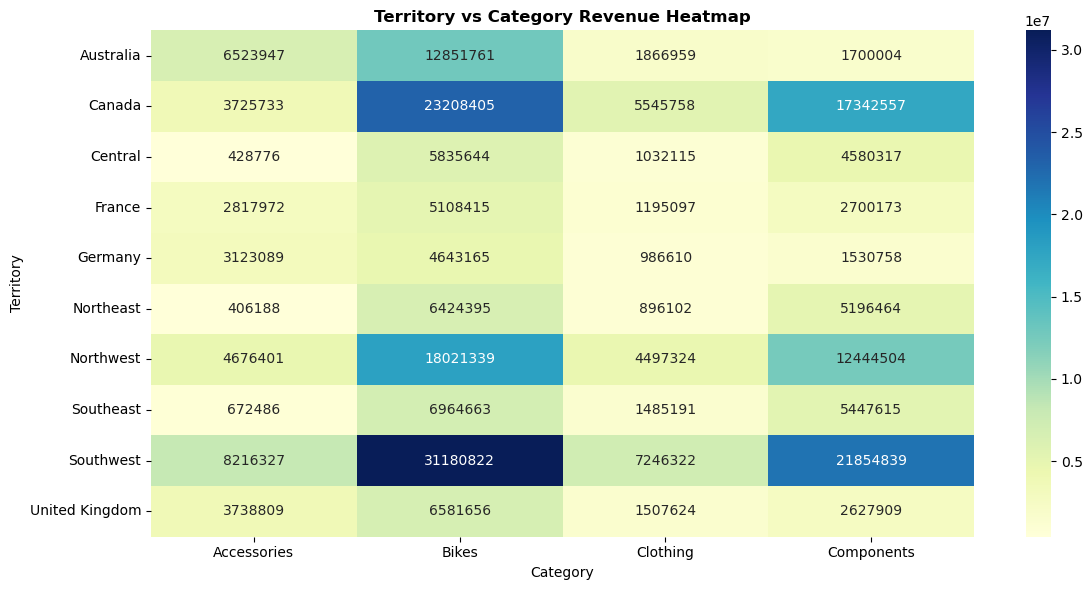

In [125]:
territory_category=df.pivot_table(index="Territory",columns="Category",values="TotalDue",aggfunc="sum",fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(territory_category,annot=True,fmt=".0f",cmap="YlGnBu")
plt.title("Territory vs Category Revenue Heatmap",fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Territory")
plt.tight_layout()
plt.show()

## Insights:
1. **Top Products**
    - By **quantity sold**:  
      - [*Sport-100 Helmet*, *Mountain-200*] was the most frequently purchased products.  
    - By **total sales value**:  
      - [*Road-650*, *Mountain Frame*] generated the highest sales .  
     
2. **Product Sizes**
   -  **Clothing**:Size M and L were the most popular sizes among customers .
   - **Bikes**: Size 48 and 44 were the most popular sizes among customers .
   - "No size" was frequent for **Accessories**, which don’t require sizing.  

3. **Product Colors**
   - **Clothing**: The most common colors were *Multi* and *Black*, while *Blue* was the least popular.  
   - **Bikes**: *Black* and *Yellow* were the most frequent colors, while *Blue* was the least common.  
   - **Components**: *Black* dominated compared to other colors.  
   - **Accessories**: Most products did not have a specified color ("No Color").  

4. **Sales by Category**  
   - Bikes generated the highest total sales compared to other categories.  
   - Clothing had the lowest overall contribution.

5. **Sales by Subcategories**  
  - Road Bikes and Mountain Bikes achieved the highest sales.  

6. **Sales by Territory**  
   - Highest sales came from **Southwest** and **Canada**.  
   - Lowest sales were in **France** and **Germany**.  

7. **Sales Trend**
   - The highest number of orders was **6,902** between **Nov 2013 – Apr 2014**.  
   - The highest sales value was **18.8M** in **March 2014**.  
   - **2013** had the highest percentage of total sales compared to other years.  
   - Sales were higher on **Mondays** and **Wednesdays**, while **Fridays** had the lowest sales.  

**Overall Summary**

- The analysis shows that: Bikes especially Road Bikes and Mountain Bikes—drive the majority of sales in both volume and value.
Performance peaked in March 2014 and overall was strongest in 2013.
Regionally, Southwest and Canada led in sales, whereas France and Germany underperformed.
Sales patterns also varied by day, with mid-week (Monday and Wednesday) showing higher activity and Friday being the weakest.

## Modeling

In [126]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
import joblib
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

df_model = df.copy()
y = df_model["TotalDue"].copy()

deploy_cols = [
    "OrderDate",
    "ItemsInOrder",
    "LineTotal",
    "Category",
    "Sub category",
    "ProductName",
    "Territory",
    "Color",
    "Size"
]

missing = [c for c in deploy_cols if c not in df_model.columns]
if missing:
    print("Warning: missing columns from df_model:", missing)

X = df_model[[c for c in deploy_cols if c in df_model.columns]].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [127]:
class OneHotEncoderDF(BaseEstimator, TransformerMixin):
    """
    Wrapper حوالين sklearn OneHotEncoder
    - يشتغل على الأعمدة في self.cols
    - يرجع DataFrame
    """

    def __init__(self, cols=None):
        self.cols = cols
        self.ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        self.feature_names_ = None

    def fit(self, X, y=None):
        X = X.copy()

        if self.cols is None:
            # لو مش متحددة، نختار كل الـ object الباقيين
            self.cols = X.select_dtypes(include=["object"]).columns.tolist()

        self.ohe.fit(X[self.cols])
        self.feature_names_ = self.ohe.get_feature_names_out(self.cols)
        return self

    def transform(self, X):
        X = X.copy()

        if not self.cols:
            return X

        ohe_array = self.ohe.transform(X[self.cols])
        ohe_df = pd.DataFrame(
            ohe_array,
            columns=self.feature_names_,
            index=X.index
        )

        # نشيل الأعمدة الكاتيجوري الأصلية
        X = X.drop(columns=self.cols)

        # ندمج الـ one-hot مع باقي الأعمدة الرقمية
        X = pd.concat([X, ohe_df], axis=1)
        return X

In [128]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    يعمل frequency encoding للأعمدة المحددة في self.cols
    هنا هنستخدمه مع:
    - "Sub category"
    - "ProductName"
    """

    def __init__(self, cols=None, normalize=False):
        self.cols = cols
        self.normalize = normalize
        self.freq_maps_ = {}

    def fit(self, X, y=None):
        X = X.copy()

        # لو المستخدم ممررش list، نستنتجها من الداتا (لكن في حالتنا هنمررها بنفسنا)
        if self.cols is None:
            self.cols = X.select_dtypes(include=["object"]).columns.tolist()

        for col in self.cols:
            if self.normalize:
                self.freq_maps_[col] = X[col].value_counts(normalize=True)
            else:
                self.freq_maps_[col] = X[col].value_counts()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            new_col = f"{col}_freq"
            X[new_col] = X[col].map(self.freq_maps_[col]).fillna(0.0)
            # نشيل العمود الأصلي عشان ما يدخلش في الـ OneHot
            X.drop(columns=[col], inplace=True)
        return X

In [129]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    - تحويل OrderDate إلى:
        OrderDay, OrderMonth, OrderYear,
        OrderWeekOfYear, OrderDayOfWeekNum,
        OrderIsWeekend, OrderDayOfYear
    - مهندسة لـ ItemsInOrder و LineTotal:
        LineTotal_per_Item, Log_LineTotal, HighValueLine
    """

    def __init__(self):
        self.global_line_mean_ = None

    def fit(self, X, y=None):
        X = X.copy()

        # متوسط LineTotal عشان نستخدمه في فلاغ high value
        if "LineTotal" in X.columns:
            self.global_line_mean_ = float(pd.to_numeric(X["LineTotal"], errors="coerce").mean())
        else:
            self.global_line_mean_ = 0.0

        return self

    def transform(self, X):
        X = X.copy()

        # ---------------------------------
        # 1) time features from OrderDate
        # ---------------------------------
        if "OrderDate" in X.columns:
            X["OrderDate"] = pd.to_datetime(X["OrderDate"], errors="coerce")

            X["OrderDay"] = X["OrderDate"].dt.day
            X["OrderMonth"] = X["OrderDate"].dt.month
            X["OrderYear"] = X["OrderDate"].dt.year
            X["OrderWeekOfYear"] = X["OrderDate"].dt.isocalendar().week.astype("Int64")
            X["OrderDayOfWeekNum"] = X["OrderDate"].dt.dayofweek  # 0=Mon .. 6=Sun
            X["OrderIsWeekend"] = X["OrderDayOfWeekNum"].isin([5, 6]).astype(int)
            X["OrderDayOfYear"] = X["OrderDate"].dt.dayofyear

            # مهم: نشيل العمود datetime عشان ما يوصلش للموديل
            X.drop(columns=["OrderDate"], inplace=True)
        else:
            X["OrderDay"] = 0
            X["OrderMonth"] = 0
            X["OrderYear"] = 0
            X["OrderWeekOfYear"] = 0
            X["OrderDayOfWeekNum"] = 0
            X["OrderIsWeekend"] = 0
            X["OrderDayOfYear"] = 0

        # تأكد إن الأعمدة دي أرقام عادية (مش Int64 pandas NA type)
        for col in ["OrderWeekOfYear", "OrderDayOfWeekNum"]:
            X[col] = pd.to_numeric(X[col], errors="coerce").fillna(0).astype(int)

        # ---------------------------------
        # 2) features من ItemsInOrder و LineTotal
        # ---------------------------------
        if "ItemsInOrder" in X.columns:
            X["ItemsInOrder"] = pd.to_numeric(X["ItemsInOrder"], errors="coerce").fillna(1).astype(float)
        else:
            X["ItemsInOrder"] = 1.0

        if "LineTotal" in X.columns:
            X["LineTotal"] = pd.to_numeric(X["LineTotal"], errors="coerce").fillna(0.0)
        else:
            X["LineTotal"] = 0.0

        # LineTotal لكل item
        X["LineTotal_per_Item"] = X["LineTotal"] / X["ItemsInOrder"].replace(0, 1)

        # log للـ LineTotal (يساعد الموديل مع القيم الكبيرة)
        X["Log_LineTotal"] = np.log1p(X["LineTotal"])

        # فلاغ لو LineTotal أعلى من متوسط السعر العام
        if self.global_line_mean_ is not None and self.global_line_mean_ > 0:
            X["HighValueLine"] = (X["LineTotal"] > self.global_line_mean_).astype(int)
        else:
            X["HighValueLine"] = 0

        return X


In [130]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

In [131]:

pipeline = Pipeline(steps=[
    ("feat_eng", FeatureEngineer()),
    ("freq_enc", FrequencyEncoder(cols=["Sub category", "ProductName"], normalize=False)),
    ("ohe_enc", OneHotEncoderDF(cols=["Category", "Territory", "Color", "Size"])),
    ("model", rf)
])


In [132]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 591.9857239299758
R2 Score: 0.9252068888075503


In [133]:
import joblib
joblib.dump(pipeline, "model.pkl")

['model.pkl']

In [134]:
df_raw = df.copy()
DEPLOY_COLS = [
    "OrderDate",
    "ItemsInOrder",
    "LineTotal",
    "Category",
    "Sub category",
    "ProductName",
    "Territory",
    "Color",
    "Size"
]

sample = df_raw[DEPLOY_COLS].sample(50).copy()


sample.to_csv("sample_for_upload.csv", index=False)
print("CSV created → sample_for_upload.csv")


model = joblib.load("model.pkl")

preds = model.predict(sample)

sample["Predicted"] = preds

sample.head(20)

CSV created → sample_for_upload.csv


,OrderDate,ItemsInOrder,LineTotal,Category,Sub category,ProductName,Territory,Color,Size,Predicted
71359,2012-08-05,1,1769.505,Bikes,Road Bikes,road-250,Southwest,Black,58,2421.996367
63670,2013-08-01,3,539.990,Bikes,Road Bikes,road-750,Southwest,Black,44,643.237627
41199,2013-11-09,4,3.990,Accessories,Tires and Tubes,road tire tube,Canada,No Color,No size,572.295418
30953,2014-06-27,2,35.000,Accessories,Tires and Tubes,mountain tire,United Kingdom,No Color,No size,473.956208
51190,2013-06-14,5,8.990,Clothing,Caps,awc logo cap,Northwest,Multi,No size,1686.182954
74625,2013-08-29,2,8.990,Clothing,Caps,awc logo cap,Southwest,Multi,No size,590.560527
76209,2014-03-01,5,1769.505,Bikes,Road Bikes,road-250,Southwest,Red,58,7526.370622
78879,2013-12-31,11,1344.588,Bikes,Road Bikes,road-550-w,Canada,Yellow,38,9740.655243
46858,2014-02-06,4,1769.505,Bikes,Mountain Bikes,mountain-200,Northwest,Silver,38,2623.256112
25416,2014-06-21,3,3.990,Accessories,Tires and Tubes,road tire tube,Germany,No Color,No size,133.018497
